# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Yiming Chen, whose
group produced the data.

## The question

A burning plasma produces helium and neutrons due to the fusion of hydrogen
isotopes. The first wall surfaces in a fusion device are bombarded by these
species with varying intensities. The degree to which implanted helium affects
the accumulation of implanted hydrogenic particles (deuterium and tritium) in
the plasma-facing walls is a first-order question for a reactor, as it impacts
the safety and fuel economy of the overall plant.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium plasma in the PISCES-A linear device at two
temperatures. Then, both these exposed samples and pristine samples were
subsequently exposed to deuterium plasma in the DIII-D tokamak via the DiMES
sample exposure probe. The retention of hydrogenic and helium species was
measured afterwards by three laboratory techniques.

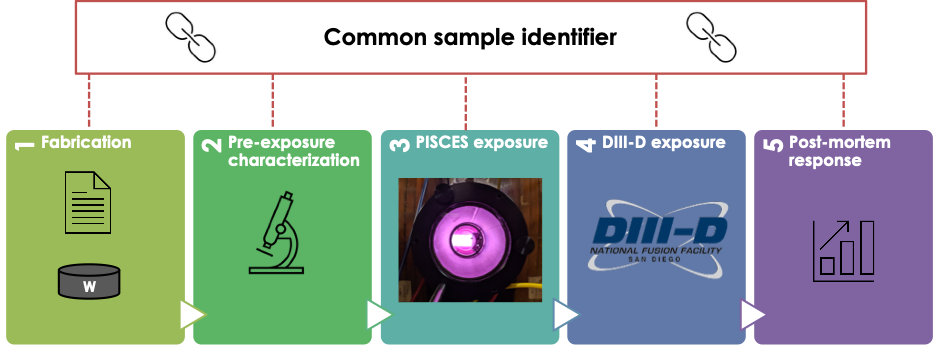

*Each coupon carries one identifier through every stage, which is what makes a
question about the end of its life answerable from the beginning of it.*

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

In [1]:
%model --name claude-fable-5-1

model,anthropic:claude-fable-5-1
provider,anthropic
api key,ANTHROPIC_API_KEY is set
configured,nrp
config file,/home/jovyan/.deepagents/config.toml


## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


The skill is read; d3d-materials has a Learnings.md on record, so reading that next for known pitfalls.

I'll plan this out: check the materials dataset for tungsten samples exposed with and without helium, compare their deuterium retention, and consult the attached literature.

The Learnings show this dataset's shape (W-HeXXX-DH/DL samples, ERDA/NRA/LAMS methods). Reading the literature skill since I'm told to search the attached papers.

Reading the materials-sample skill instructions to learn how to query samples, exposures and retention measurements.

The skill's Learnings.md exists; reading it for known pitfalls before writing any query code.

...

All computations succeeded in one pass. Marking the remaining steps complete before writing the report.

Writing the analysis script: percentage change in D retention vs the no-He control for each method, DIII-D regime and He level, with ERDA/LAMS uncertainties propagated, plus the charts.

Running the analysis and plotting script.

All three figures saved cleanly. Marking the analysis complete before writing the report.

**Short answer** : In this delivery (nine W coupons, PISCES He pre-exposure then DIII-D D plasma), helium does not have one effect on D retention — it depends on the He exposure temperature and the DIII-D regime. The 800 K He layer followed by ELMy H-mode is the one case where every technique agrees D retention fell: ERDA −42 ± 5 %, NRA −68 % (0–0.5 µm) and −77 % (0.5–3 µm), LAMS −50 ± 25 % (integrated 0.02–2.16 µm) relative to the no-He control. The 600 K He layer produced no reduction in H-mode (ERDA +27 ± 9 %), and in L-mode the techniques disagree about the sign of the change — ERDA and near-surface NRA report more D on the He coupons, while sub-surface NRA and LAMS report less. In all ten technique/regime comparisons, the 800 K coupon retained less D than its 600 K counterpart.

## The experiment

- **Samples** : 9 W coupons, one per design cell (no replication). Two no-He controls (W-DH, W-DL), four He-pre-exposed coupons (W-He600-DH, W-He800-DH, W-He600-DL, W-He800-DL), and three that never entered DIII-D (W-pristine, W-He600, W-He800).
- **PISCES He pre-exposure** (Exposure 1, 70 eV He, Russ Doerner): 800 K level = 2.83e22 m⁻² s⁻¹ for 480 s (1.2e25 m⁻²); 600 K level = 4.1e21 m⁻² s⁻¹ for 4260 s (1.0e25 m⁻²). The two "temperature" levels therefore also differ 7× in flux and 9× in duration at near-equal fluence.
- **DIII-D D exposure** (Exposure 2, 2021-03-15, DiMES, Greg Sinclair): H-mode shots 185258–185260, 185265, 185266 (150 eV, 4.5e21 m⁻² s⁻¹, 12.5 s, 6.7e22 m⁻², 0.72 MW m⁻²); L-mode shots 185261–185264 (175 eV, 7.5e21 m⁻² s⁻¹, 10 s, 7.8e22 m⁻², 0.47 MW m⁻²). Sample temperature during DIII-D exposure was not measured.

## D retention by technique


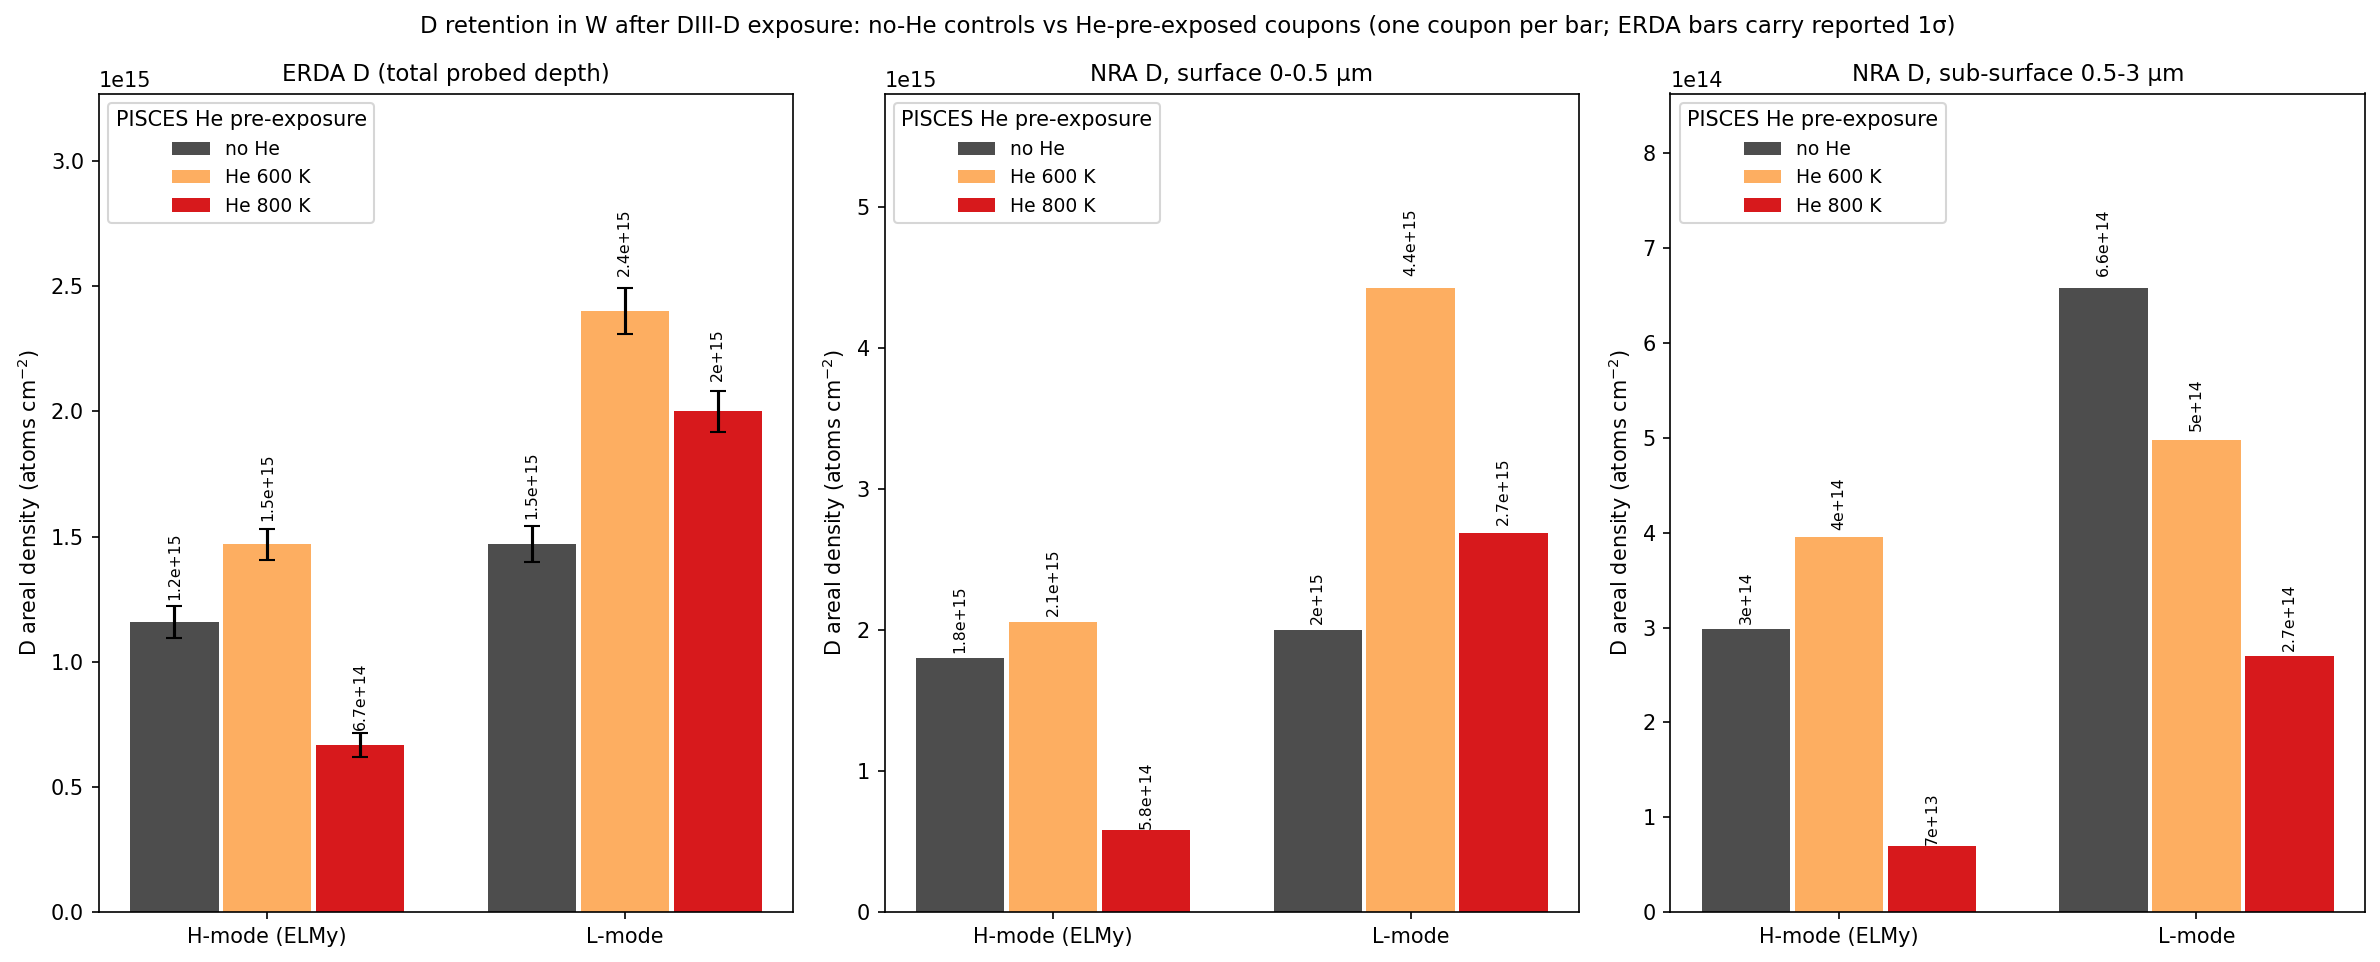

| Sample | He pre-exp. | DIII-D | ERDA D (atoms cm⁻², ±1σ) | NRA D 0–0.5 µm (atoms cm⁻²) | NRA D 0.5–3 µm (atoms cm⁻²) |
|---|---|---|---|---|---|
| W-DH | none | H-mode | 1.16e15 ± 6.3e13 | 1.80e15 | 2.98e14 |
| W-He600-DH | 600 K | H-mode | 1.47e15 ± 6.2e13 | 2.06e15 | 3.95e14 |
| W-He800-DH | 800 K | H-mode | 6.68e14 ± 4.8e13 | 5.82e14 | 6.96e13 |
| W-DL | none | L-mode | 1.47e15 ± 7.1e13 | 2.00e15 | 6.57e14 |
| W-He600-DL | 600 K | L-mode | 2.40e15 ± 9.1e13 | 4.42e15 | 4.97e14 |
| W-He800-DL | 800 K | L-mode | 2.00e15 ± 8.3e13 | 2.69e15 | 2.70e14 |
| W-pristine | none | none | not measured | 0 | 0 |
| W-He600 | 600 K | none | not measured | 9.7e13 | 6.2e12 |
| W-He800 | 800 K | none | not measured | 3.1e13 | 0 |

NRA reported no uncertainties. ERDA D on the three coupons that never entered DIII-D was not measured (the provider confirms the zeros in the file were an error).


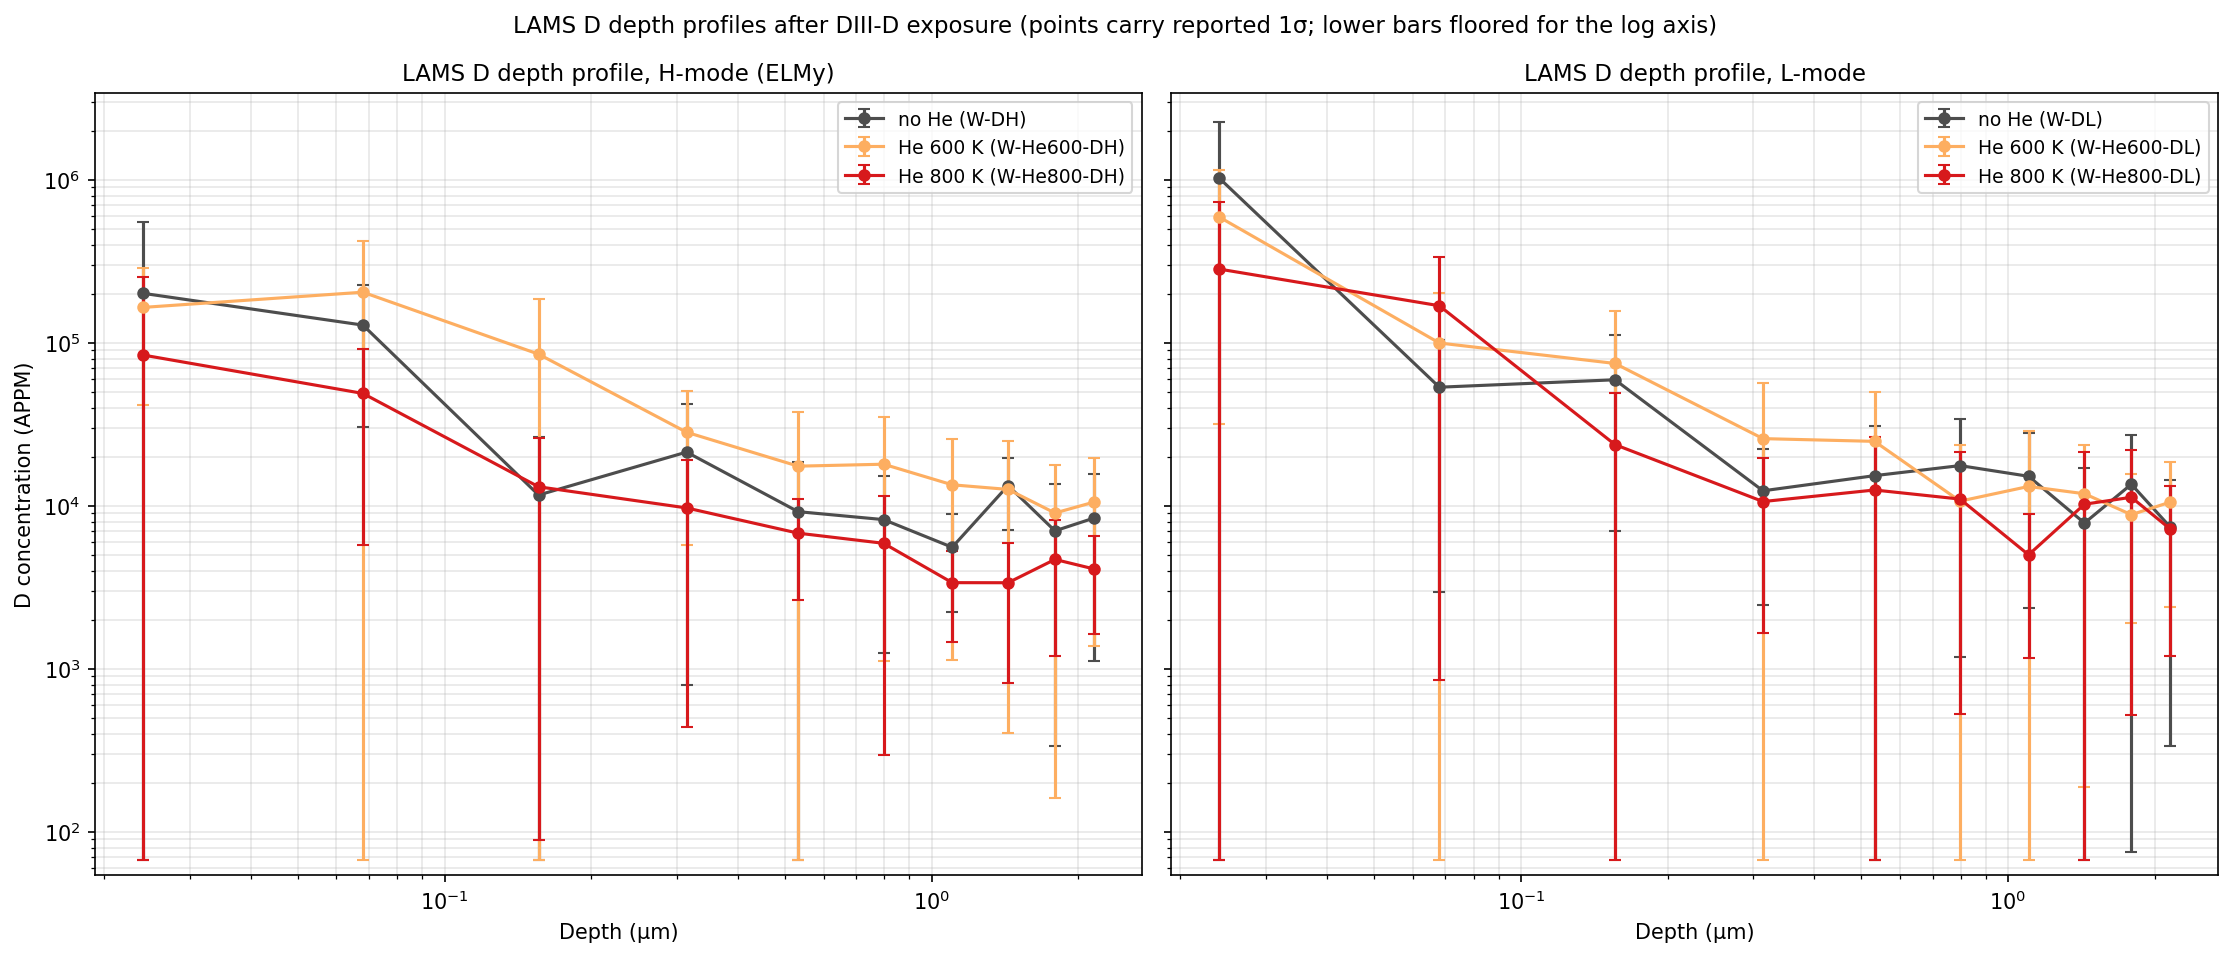

LAMS profiles (10 points, 0.024–2.155 µm, APPM) are strongly surface-peaked in every DIII-D-exposed coupon. Their reported per-point σ is large — often comparable to the value — so LAMS changes below are mostly not significant on their own.

## Change in D retention vs the no-He control

"Change vs control" is $100\,(D_\mathrm{He}/D_\mathrm{control} - 1)$ for the coupon pair sharing the same DIII-D campaign; σ is propagated from the two reported 1σ values where the technique gave them. The LAMS integrated column is $\int c\,dz$ by trapezoid over the 10 profile points (APPM·µm), a technique-internal measure that is not converted to atoms cm⁻² (the delivery says the techniques are not interchangeable).


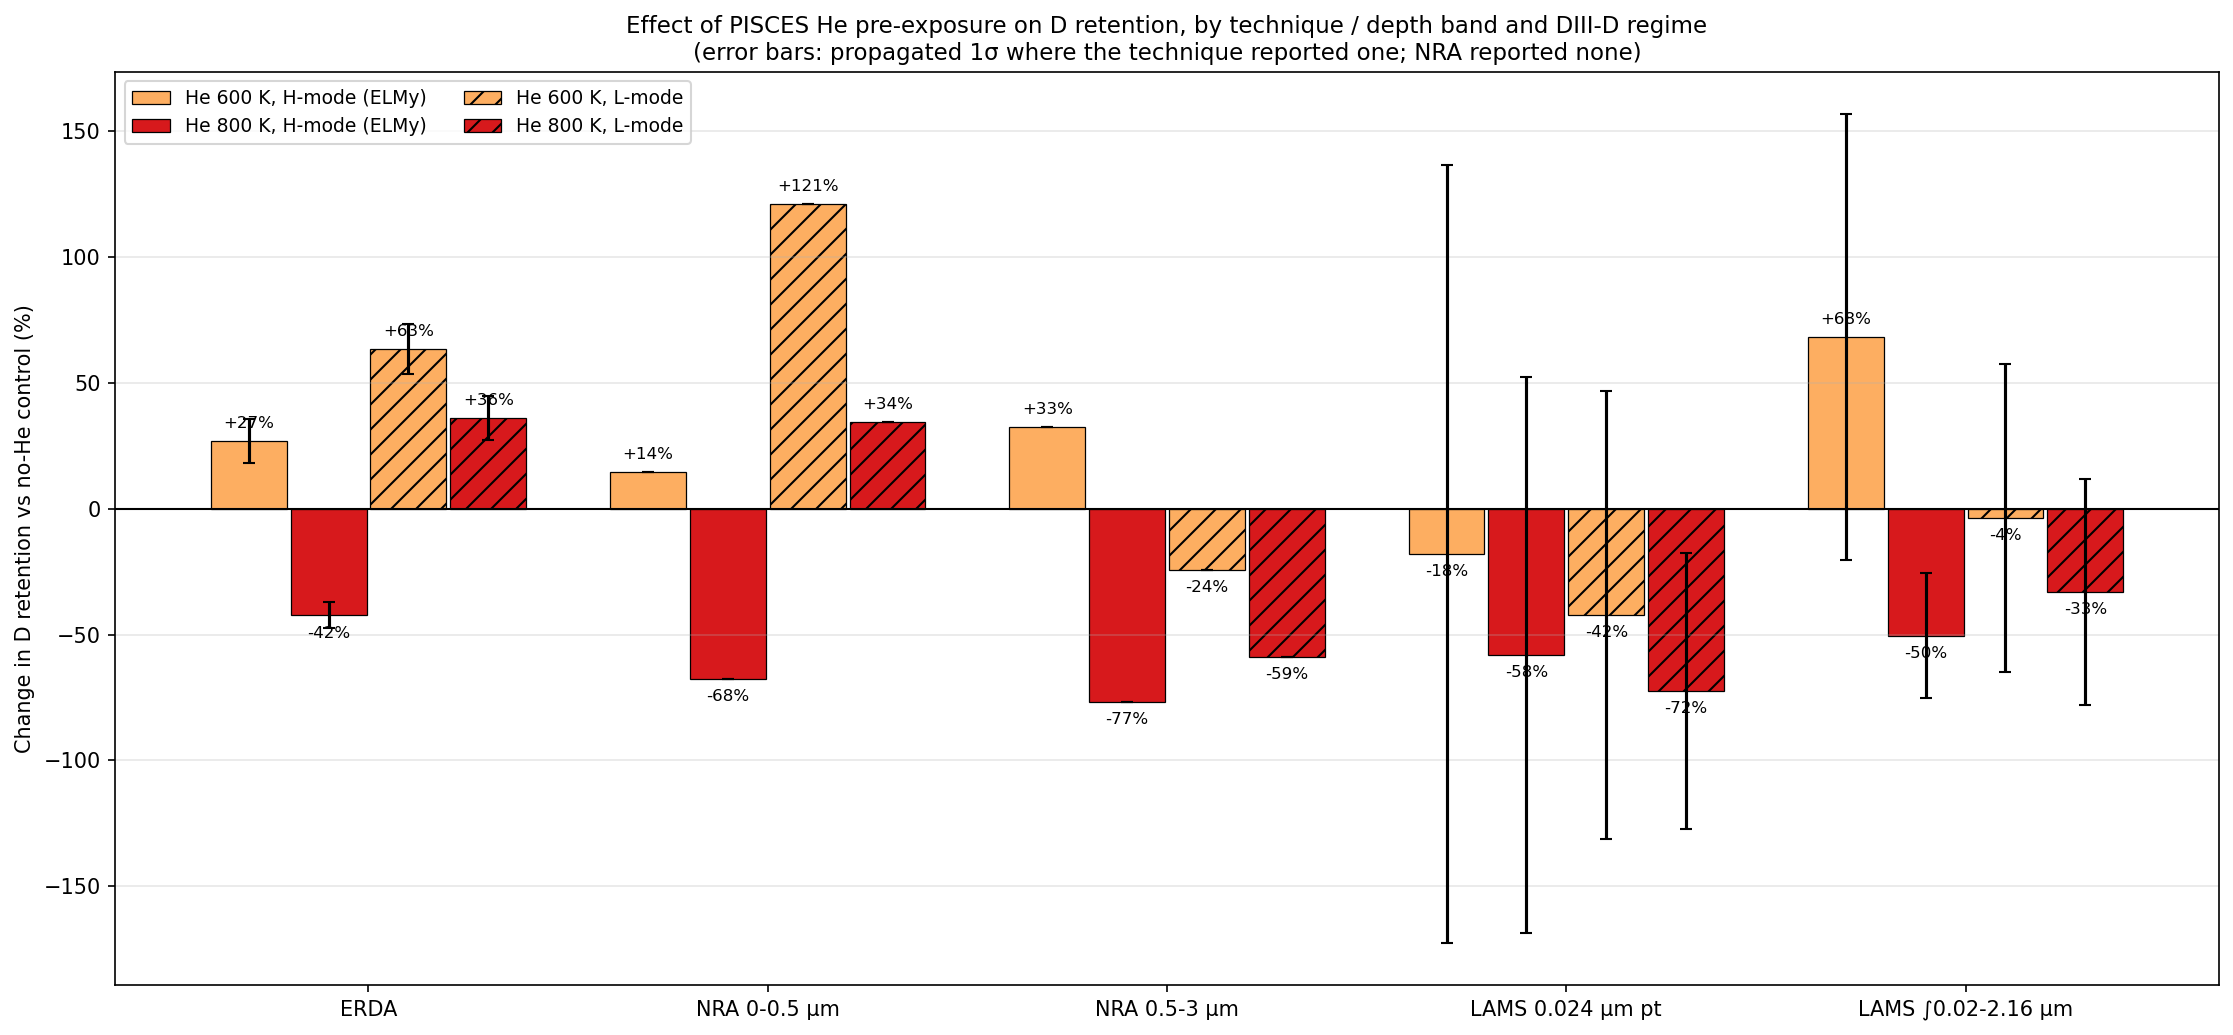

| Technique / band | H-mode, He 600 K | H-mode, He 800 K | L-mode, He 600 K | L-mode, He 800 K |
|---|---|---|---|---|
| ERDA | +27 ± 9 % | −42 ± 5 % | +63 ± 10 % | +36 ± 9 % |
| NRA 0–0.5 µm | +14 % | −68 % | +121 % | +35 % |
| NRA 0.5–3 µm | +33 % | −77 % | −24 % | −59 % |
| LAMS ∫0.02–2.16 µm | +68 ± 89 % | −50 ± 25 % | −4 ± 61 % | −33 ± 45 % |
| LAMS first point (0.024 µm) | −18 ± 154 % | −58 ± 110 % | −42 ± 89 % | −72 ± 55 % |

What the table shows:

1. **800 K He + H-mode is the only cell where all techniques agree on a reduction** (−42 % to −77 %; the LAMS surface point agrees in sign but not significantly).
2. **600 K He + H-mode shows no reduction.** ERDA and both NRA bands report more D than the control; the LAMS changes are within their σ.
3. **In L-mode the techniques split by depth.** ERDA (whole probed depth) and NRA 0–0.5 µm report more D on both He coupons (+35 % to +121 %); NRA 0.5–3 µm and LAMS report less (−24 % to −72 %, the LAMS values largely within σ). The delivery's guidance is that the techniques differ in probing depth and are not to be reconciled or ranked, so this disagreement is reported as a result.
4. **Ordering by He temperature is unanimous** : in all 10 (technique, regime) pairs the 800 K coupon holds less D than the 600 K coupon.
5. **Sub-surface D (NRA 0.5–3 µm) is lower on 3 of the 4 He coupons** than on their control; the exception is W-He600-DH (+33 %). The NRA sheet's own analyst observation, restated under the corrected sample names, is that sub-surface D is lower in the 800 K He coupons and lower after H-mode than after L-mode — both hold in the lakehouse values. The same sheet notes sub-surface D is above the ~10 appm detection limit and "higher than seen in previous similar study [Wampler et. al. JNM 415 2011 S653]".

## Two things that qualify the comparison

- **The no-He controls are not He-free after DIII-D.** ERDA He: W-pristine 0; W-DH 3.04e15 ± 9.6e13; W-DL 2.00e15 ± 7.8e13 atoms cm⁻² — comparable to the He-only coupons (W-He800 3.00e15, W-He600 3.97e15) and to the He-pre-exposed DIII-D coupons (2.53e15–3.74e15). The LAMS sheet's analyst (Garcia) also notes "All DH samples show He and D present in significant quantities". So the comparison is between a PISCES-grown He layer plus DIII-D He and DIII-D He alone, not He versus no He.
- **One coupon per cell.** Every difference above is between two individual coupons; coupon-to-coupon variation cannot be separated from the treatment effect, however far outside the ERDA 1σ it lies.

## What the He layer did to the surface (delivered evidence)

The only imaging in the delivery is pre-DIII-D SEM (JEOL JSM-7000F, stage "pre-characterization") of W-pristine, W-He600 and W-He800 — 3 of 9 coupons; none of the six DIII-D-exposed coupons was imaged, and no post-DIII-D image exists, so the effect of the D exposure on the surface cannot be assessed from pictures. These images do document the PISCES He treatment that the -DH/-DL coupons also received (same exposure IDs 17 and 18).


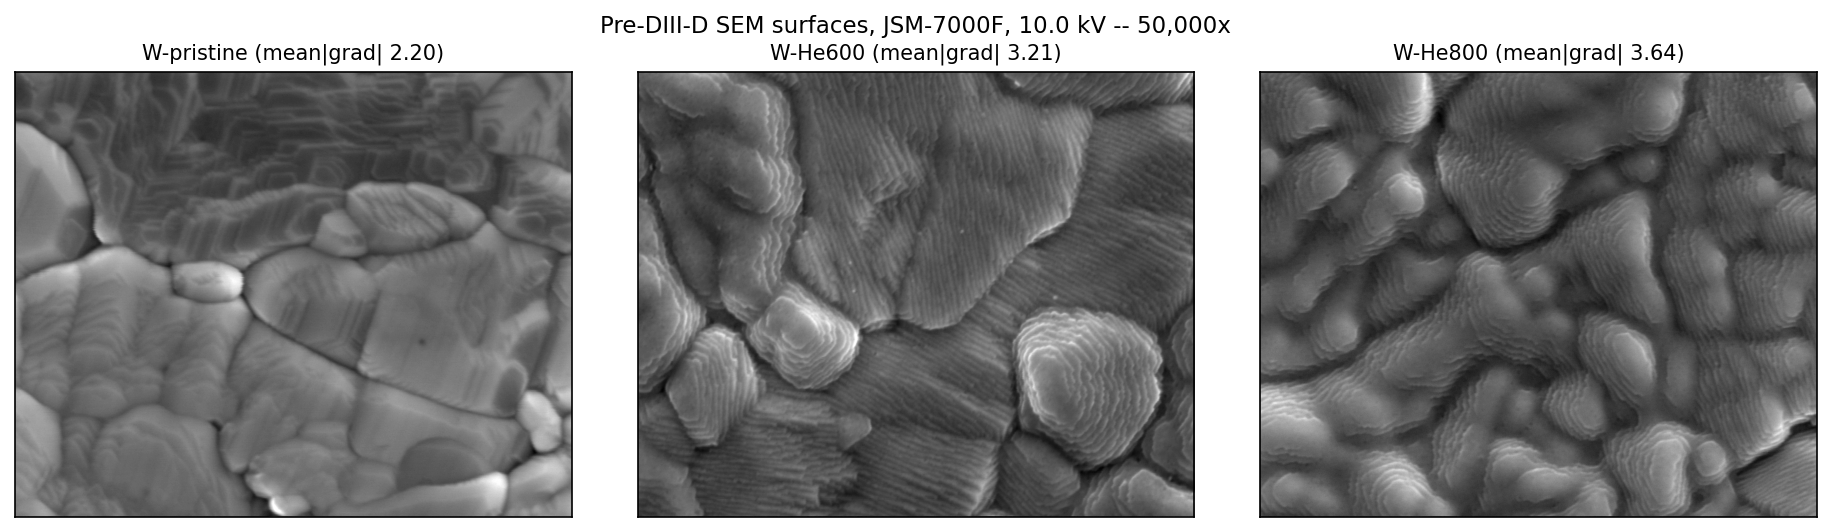

Settings chosen as the combination all three samples share (50,000×, 10 kV; 81 deduplicated images from 162 delivered files). Texture statistic = mean absolute grey-level gradient per pixel over the top 90 % of the frame (higher = more fine-scale surface structure), measured on every image at those settings:

| Sample | Images | Mean gradient (mean) | Range |
|---|---|---|---|
| W-pristine | 4 | 2.20 | 2.11–2.42 |
| W-He600 | 6 | 3.21 | 1.84–4.46 |
| W-He800 | 8 | 3.64 | 2.78–6.03 |

Both He-exposed surfaces are rougher at this scale than the pristine one, and the 800 K surface is the roughest on average — the same ordering as D retention (800 K < 600 K) — though the per-image ranges overlap. No pixel-size calibration was found in the companion metadata, so no feature size is quoted.

## Published context

The proposal delivered with the samples (MP_W_erosion_retention_2020_v9.pdf, L48–52) states the hypothesis being tested: findings in its ref. [8] "suggested that implanted He acts as a permeation barrier for incident D+ ions, inhibiting transport and reducing D retention", and that higher-energy intra-ELM D⁺ ions are more likely to cross the barrier than low-energy ions (L59–61). That reference is the attached paper by Baldwin and Doerner (2017), whose PISCES-A TDS experiments on Plansee W (He at 473–550 K, D at 573 K, 60–80 eV) found D release consistent with "the He nanobubble layer acting as a permeation barrier" and concluded that "both mechanisms of altered transport and altered recycling are thought to contribute to the He induced reduced hydrogen isotope retention effect in W." That is their result on their coupons. In the present delivery the reduction appears cleanly only for the 800 K layer under ELMy H-mode; the 600 K layer and the L-mode exposures do not reproduce it by ERDA, and the sub-surface NRA band is the only measure that reduces in most He cells.

## Data files

- `he_effect_scalar_retention.csv` — every ERDA (D, H, He) and NRA (D, both bands) row for the 9 coupons with `measured` flag, value, σ, unit.
- `he_effect_lams_profiles.csv` — LAMS D and He depth profiles (10 points × 9 coupons), value and σ.
- `he_effect_change_vs_control.csv` — the change-vs-control table above with control/He coupon names, values, σ.
- `he_effect_exposure_conditions.csv` — PISCES and DIII-D campaign conditions (exposures 17–20).
- `sem_texture_stats.csv` — per-image mean gradient at 50,000×/10 kV.
- `workbook_analyst_notes_excerpt.txt`, `proposal_he_barrier_excerpt.txt` — the sheet commentary and proposal lines quoted above, as read from the delivered documents in this run.
- `he_effect_literature_hits.json` — literature passages returned with citations.

## References

- M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

In [5]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


In [ ]:
%%ask
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

No prior results recorded — the folder name indicates the topic is the helium effect on retention in materials samples. Reading the materials skill instructions.

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


In [ ]:
%%ask
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used. 

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


In [ ]:
%%ask
Given these tungsten samples and the retention measurements delivered with
them, what do the results collectively support, what would they not be
sufficient to claim, and what further measurement would be needed?